# 📊 Amazon Reviews '23 - EDA for Content-Based Retrieval

### Categories: All_Beauty, Appliances, Gift_Cards  
### Goals: Understand rating behavior, temporal trends, text distribution, and metadata quality

---

## 🗂️ 1. Load and Preview Data

- Load user and metadata files
- Join on `parent_asin`
- Basic sanity checks

---

## 📈 2. Rating Behavior Analysis (Method 1 & 2 Support)

- Histograms of ratings
- Rating count per item
- Relationship: rating count vs average rating

---

## 🕒 3. Time-Based Review Trends (Trending Retrieval)

- Reviews over time
- Time-series patterns per category
- Trend of average rating or positivity

---

## 💬 4. Textual Review Analysis

- Review length distribution
- Sentiment distribution
- Frequent positive/negative terms

---

## 🧾 5. Metadata Insights

- Price distribution
- Brand/store distributions
- Categories, features, missing values

---

## 🧠 6. Embedding / Prep for Two-Tower Models (Optional)

- Text vectorization (TF-IDF or embeddings)
- Visualizing distributions with PCA/UMAP

---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# load data
user_df = pd.read_json("Data/All_Beauty_UserReview.jsonl", lines=True)
meta_df = pd.read_json("Data/meta_All_Beauty.jsonl", lines=True)

# Merge on parent_asin
df = pd.merge(user_df, meta_df, on="parent_asin", how="left")

df['date'] = pd.to_datetime(df['timestamp'], unit='s') # seconds

# Show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

df.head(5)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\GaryBao\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,rating,title_x,text,images_x,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,main_category,title_y,average_rating,rating_number,features,description,price,images_y,videos,store,categories,details,bought_together,date
0,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True,All Beauty,Herbivore - Natural Sea Mist Texturizing Salt ...,4.3,384,[],"[If given the choice, weÕd leave most telltale...",NaN,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Best Hair Product For Summer!', 'u...",HERBIVORE,[],"{'Hair Type': 'Wavy', 'Material Type Free': 'D...",NaN,2020-05-05 14:08:48.923
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True,All Beauty,All Natural Vegan Dry Shampoo Powder - Eco Fri...,4.0,56,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Easy to apply!', 'url': 'https://w...",Two Goats Apothecary,[],"{'Brand': 'Two Goats Apothecary', 'Item Form':...",NaN,2020-05-04 18:10:55.070
2,5,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True,All Beauty,New Road Beauty - Creamsicle - Variety 3 Pack ...,4.4,699,"[Same Great Product, NEW PACKAGING., MOISTURIZ...",[New Road Beauty Paraffin Wax is recommended f...,21.98,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Opening the Creamsicle assortment ...,New Road Beauty,[],{'Package Dimensions': '10.5 x 6.4 x 1.6 inche...,NaN,2020-05-16 21:41:06.052
3,1,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,0,True,All Beauty,muaowig Ombre Body Wave Bundles 1B Grey Human ...,1.0,1,[?Hair Bundle Material?:Brazilian Virgin Human...,[Hair Material: Brazilian Virgin Human Hair Bu...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],muaowig,[],"{'Brand': 'muaowig', 'Material': 'Human Hair',...",NaN,2022-01-28 18:13:50.220
4,5,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-30 10:02:43.534,0,True,All Beauty,Yinhua Electric Nail Drill Kit Portable Profes...,3.5,20,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Yinhua,[],{'Package Dimensions': '8.5 x 3.82 x 2.24 inch...,NaN,2020-12-30 10:02:43.534


In [18]:
print(df.shape, meta_df.shape)

(701528, 26) (112590, 14)


In [4]:
df.columns


Index(['rating', 'title_x', 'text', 'images_x', 'asin', 'parent_asin',
       'user_id', 'timestamp', 'helpful_vote', 'verified_purchase',
       'main_category', 'title_y', 'average_rating', 'rating_number',
       'features', 'description', 'price', 'images_y', 'videos', 'store',
       'categories', 'details', 'bought_together'],
      dtype='object')

## 2. Rating Behavior Analysis

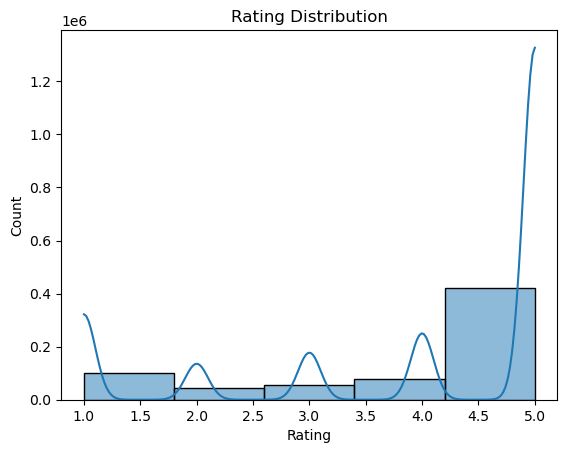

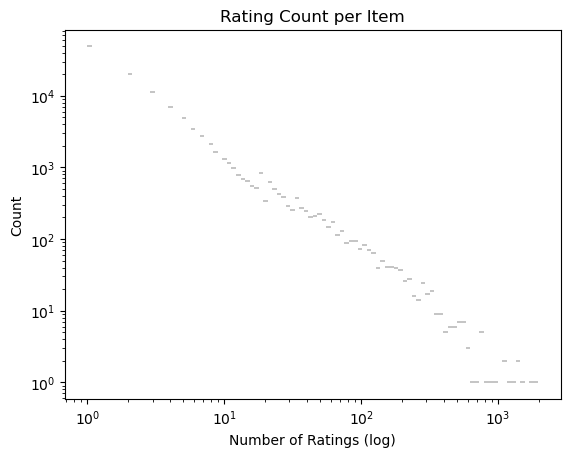

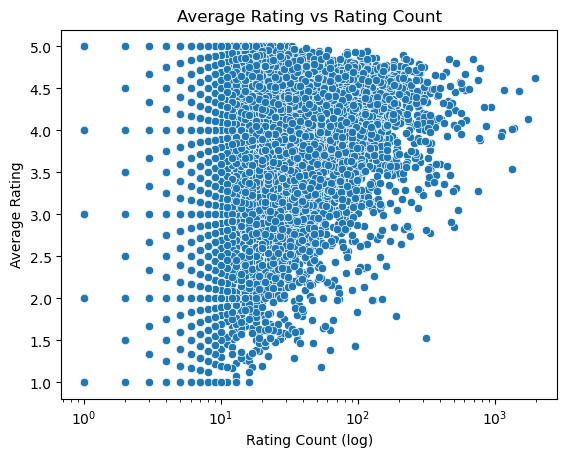

In [7]:
# Ratings distribution
sns.histplot(df['rating'], bins=5, kde=True)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# Rating count per item
rating_counts = df.groupby('asin')['rating'].count().sort_values(ascending=False)
sns.histplot(rating_counts, bins=100, log_scale=(True, True))
plt.title('Rating Count per Item')
plt.xlabel('Number of Ratings (log)')
plt.show()

# Relationship: rating_count vs. average_rating
avg_rating_per_item = df.groupby('asin')['rating'].mean()
merged_stats = pd.DataFrame({
    'average_rating': avg_rating_per_item,
    'rating_count': rating_counts
}).dropna()

sns.scatterplot(data=merged_stats, x='rating_count', y='average_rating')
plt.xscale('log')
plt.title('Average Rating vs Rating Count')
plt.xlabel('Rating Count (log)')
plt.ylabel('Average Rating')
plt.show()


## 3. Time-Based Trends

In [14]:
df.columns

Index(['rating', 'title_x', 'text', 'images_x', 'asin', 'parent_asin',
       'user_id', 'timestamp', 'helpful_vote', 'verified_purchase',
       'main_category', 'title_y', 'average_rating', 'rating_number',
       'features', 'description', 'price', 'images_y', 'videos', 'store',
       'categories', 'details', 'bought_together', 'rolling_avg', 'sentiment',
       'positive', 'review_len'],
      dtype='object')

<Axes: title={'center': 'Reviews Over Time'}, xlabel='timestamp'>

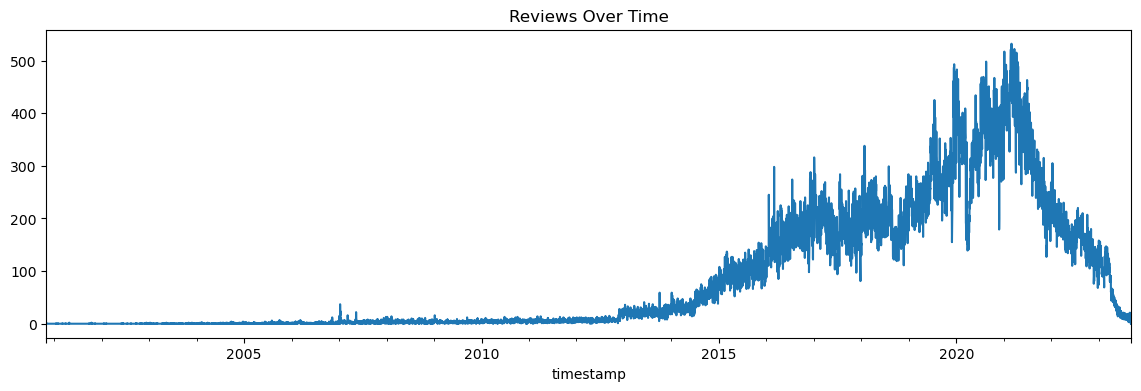

In [15]:
# Total reviews over time
df.set_index('timestamp', inplace=True)
df['rating'].resample('D').count().plot(figsize=(14, 4), title='Reviews Over Time')

<Axes: title={'center': '3-Day Rolling Average Rating'}, xlabel='timestamp'>

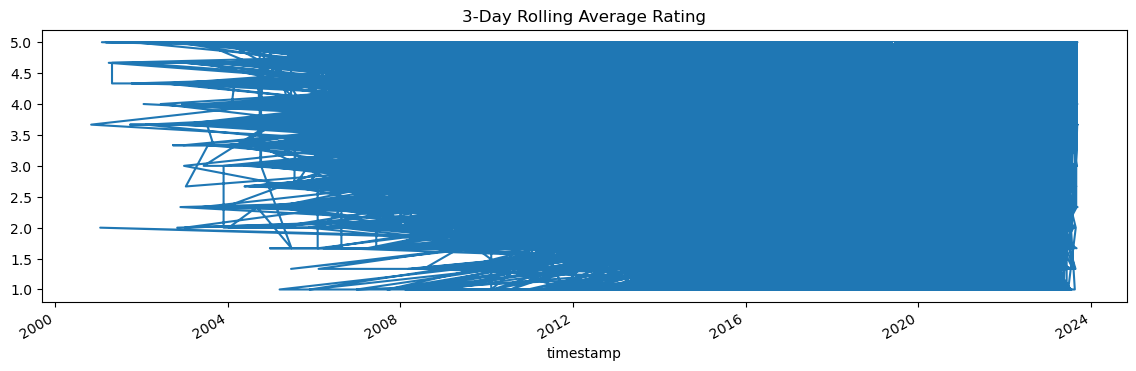

In [16]:
# 3-day rolling avg rating
df['rolling_avg'] = df['rating'].rolling(window=3).mean()
df['rolling_avg'].plot(figsize=(14, 4), title='3-Day Rolling Average Rating')

<Axes: title={'center': 'Weekly % of Positive Reviews'}, xlabel='date'>

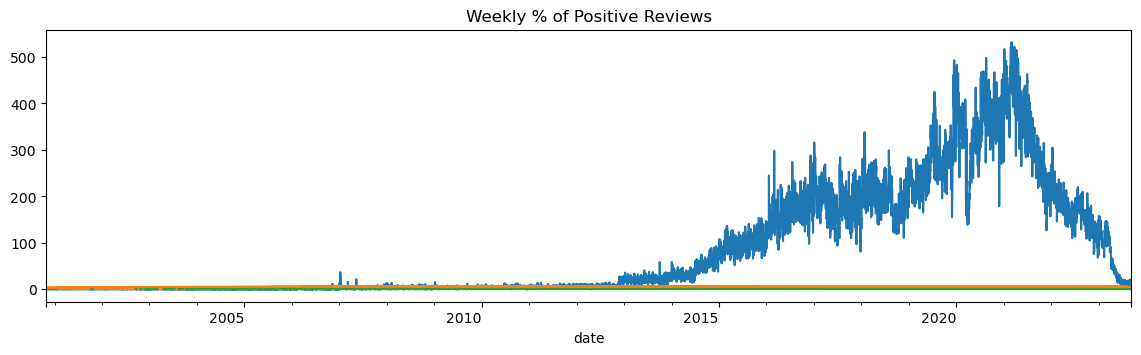

In [ ]:

# Weekly positivity trend (sentiment-based)
df['sentiment'] = df['text'].apply(lambda x: sia.polarity_scores(x)['compound'])
df['positive'] = df['sentiment'] > 0.3
weekly_positive = df.resample('W')['positive'].mean()
weekly_positive.plot(title='Weekly % of Positive Reviews')


## 4. Textual Review Analysis

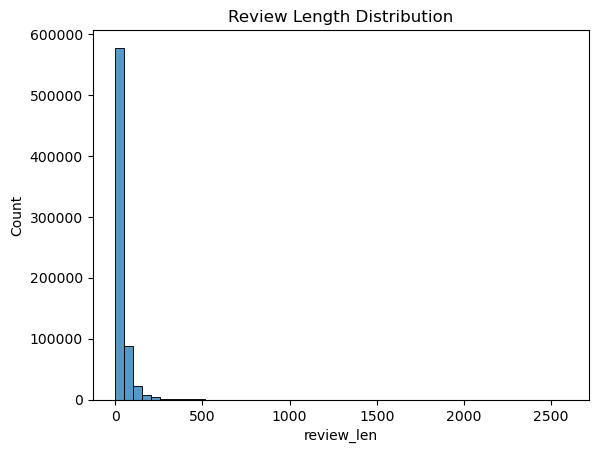

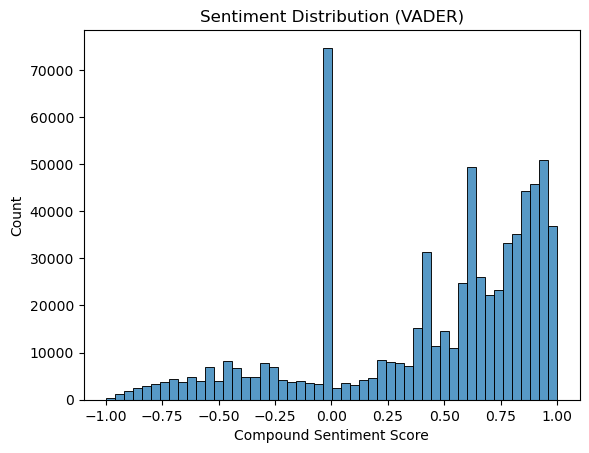

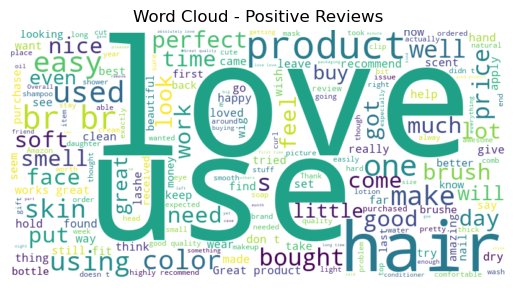

In [9]:
# Review length
df['review_len'] = df['text'].apply(lambda x: len(str(x).split()))
sns.histplot(df['review_len'], bins=50)
plt.title('Review Length Distribution')
plt.show()

# Sentiment distribution
sns.histplot(df['sentiment'], bins=50)
plt.title('Sentiment Distribution (VADER)')
plt.xlabel('Compound Sentiment Score')
plt.show()

# Word cloud for positive reviews
positive_reviews = ' '.join(df[df['positive']]['text'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Reviews')
plt.show()


### 5. Metadata EDA

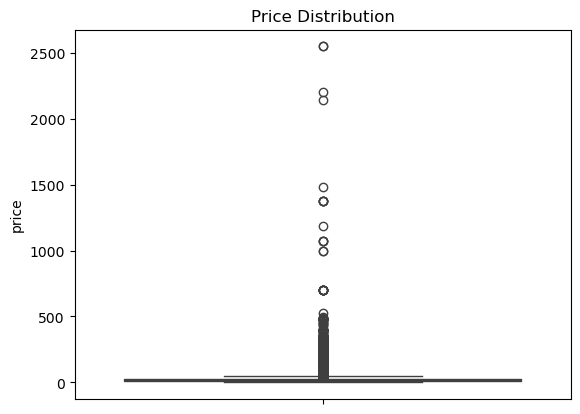

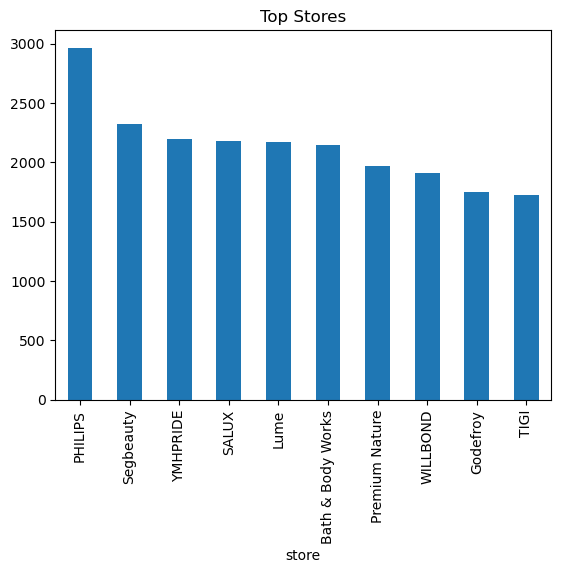

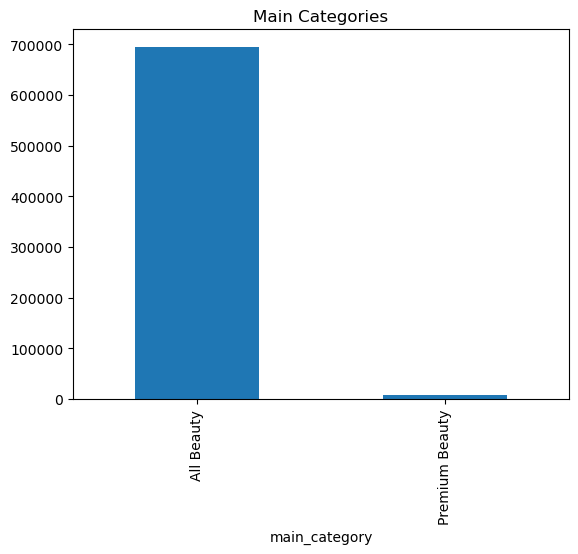

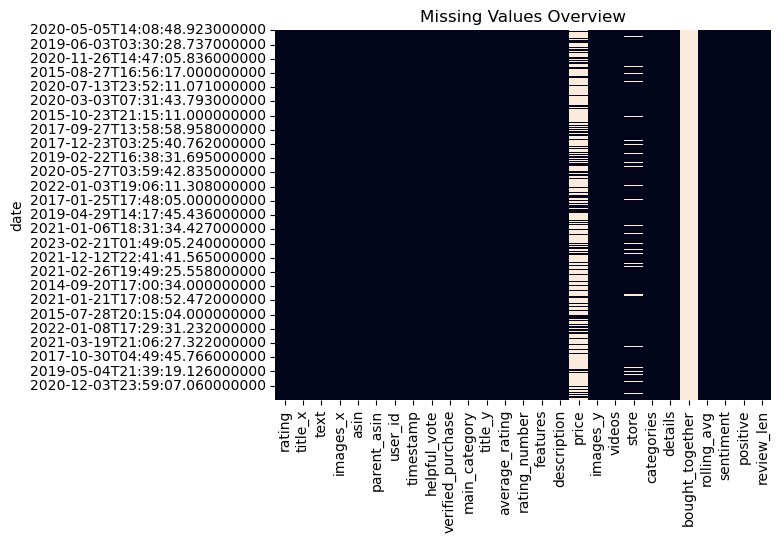

In [10]:
# Price distribution
df['price'] = pd.to_numeric(df['price'], errors='coerce')
sns.boxplot(df['price'])
plt.title('Price Distribution')
plt.show()

# Top brands/stores
df['store'].value_counts().head(10).plot(kind='bar', title='Top Stores')
plt.show()

# Category breakdown (if categorical)
df['main_category'].value_counts().head(10).plot(kind='bar', title='Main Categories')
plt.show()

# Missing value heatmap
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values Overview')
plt.show()


### 6. Embedding Prep for Two-Tower

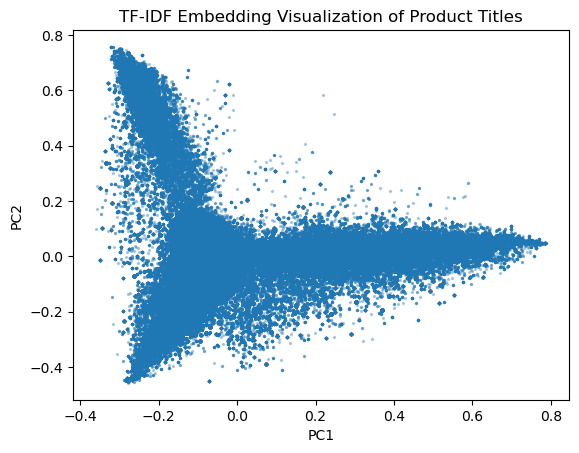

In [12]:
# Vectorize item titles
tfidf = TfidfVectorizer(max_features=100)
X = tfidf.fit_transform(df['title_y'].dropna().astype(str))

# PCA to 2D
pca = PCA(n_components=2)
reduced = pca.fit_transform(X.toarray())

# Plot
plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.3, s=2)
plt.title('TF-IDF Embedding Visualization of Product Titles')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()
